In [9]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.plot import *
from mis_dro.experiments import ExperimentName
from mis_dro.dataset import *
from mis_dro.newsvendor import newsvendor_cost_cvxpy

# from matplotlib import rc
# rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], "size":12})
# rc('text', usetex=True)

In [10]:
experiment_name = ExperimentName.kl_newsvendor_1d
experiment_dir = Path(f"/Users/patrick/experiments/misdro/paper-bas/{experiment_name.value}")
# experiment_dir = Path(f"/dcs/large/u1508153/misdro/dro_bas/{experiment_name.value}")
assert experiment_dir.exists()
all_results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])

num_total_samples = []
for _, row in all_results_df.iterrows():
    if row["algorithm"] == "kl_bdro":
        num_total_samples.append(row["num_likelihood_samples"] ** 2)
    elif row["algorithm"] == "kl_dro_bas":
        num_total_samples.append(row["num_likelihood_samples"])
all_results_df["num_total_samples"] = num_total_samples
all_results_df

mean_cost     var_cost  \
uuid                                 replication                            
0a825e16-7dbb-473b-b549-0808e679a621 0                   inf     0.000000   
                                     1                   inf     0.000000   
                                     2                   inf     0.000000   
                                     3                   inf     0.000000   
                                     4                   inf     0.000000   
...                                                      ...          ...   
35879cbc-18ad-4b2e-bde9-774f4d42550e 195          212.261919  1023.503374   
                                     196          166.078280   608.042652   
                                     197          201.428755  1309.403211   
                                     198           86.825472   709.888298   
                                     199          214.176202   758.435046   

                                                   solution  dgp_time  \
uuid                                 replication                        
0a825e16-7dbb-473b-b549-0808e679a621 0                  inf  0.000225   
                                     1                  inf  0.000537   
                                     2                  inf  0.000492   
                                     3                  inf  0.000617   
                                     4                  inf  0.000576   
...                                                     ...       ...   
35879cbc-18ad-4b2e-bde9-774f4d42550e 195          80.883094  0.000595   
                                     196          62.962937  0.000415   
                                     197          79.209832  0.000358   
                                     198          38.579425  0.000507   
                                     199          82.080815  0.000518   

                                                  likelihood_time  \
uuid                                 replication                    
0a825e16-7dbb-473b-b549-0808e679a621 0                   0.000017   
                                     1                   0.000030   
                                     2                   0.000031   
                                     3                   0.000031   
                                     4                   0.000026   
...                                                           ...   
35879cbc-18ad-4b2e-bde9-774f4d42550e 195                 0.004376   
                                     196                 0.002407   
                                     197                 0.002750   
                                     198                 0.002919   
                                     199                 0.002723   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
0a825e16-7dbb-473b-b549-0808e679a621 0                  0.000079    0.000002   
                                     1                  0.000139    0.000004   
                                     2                  0.000136    0.000004   
                                     3                  0.000150    0.000004   
                                     4                  0.000118    0.000003   
...                                                          ...         ...   
35879cbc-18ad-4b2e-bde9-774f4d42550e 195                0.000169    0.948364   
                                     196                0.000111    0.751532   
                                     197                0.000100    0.831697   
                                     198                0.000118    0.861347   
                                     199                0.000155    0.801023   

                                                  setup_time  \
uuid                                 replication               
0a825e16-7dbb-473b-b549-0808e679

In [11]:
# NOTE filter by DGP
filter_dgp = "truncated_normal"
results_df = all_results_df.loc[all_results_df["dgp"] == filter_dgp]

# NOTE filter out when log_partition_constant G is less than epsilon
results_df = results_df.loc[results_df["log_partition_constant"] < results_df["epsilon"]]

def convert_str_to_float_list(str_list: str, list_len: int) -> list[float]:
    if str_list == "[]":
        return [np.nan for _ in range(list_len)]
    else:
        return [float(x) for x in str_list.strip('[]').split(',')]

# NOTE we always want the same number of test observations
assert np.isclose(results_df["num_test_observations"].var(), 0)
# num_test_observations = results_df["num_test_observations"].unique()[0]
# results_df["out_of_sample_cost"] = results_df["out_of_sample_cost"].map(lambda x: convert_str_to_float_list(x, num_test_observations))

# special case for 1 test observation
# if num_test_observations == 1:
    # results_df["out_of_sample_cost"] = results_df["out_of_sample_cost"].map(lambda x: x[0])
# else:
    # raise NotImplementedError("Not supported yet!")

# results_df["out_of_sample_cost"]

In [12]:

num_observations = results_df["num_observations"].unique()[0]
num_test_observations = 1
dim = 1
dgp = filter_dgp
single_test_observation = []

def get_agg_df(results_df: pd.DataFrame, gb_cols: list[str]):
    

    for idx, df in results_df.groupby(gb_cols + ["replication"]):

        algorithm, dgp, epsilon, num_total_samples, replication = idx
        generator = np.random.default_rng(seed=replication)
        # NOTE if contamination is specified, then only contaminate the training samples (not test samples)
        data = sample_dgp(
            dgp, num_observations, dim=dim, contamination=0.0, generator=generator
        )
        data_eval = sample_dgp(
            dgp, num_test_observations, dim=dim, contamination=0.0, generator=generator
        )
        x = np.array([df["solution"].iloc[0]])
        # x = np.array([float(x) for x in df["solution"].iloc[0].strip('[]').split(',')])
        xi = data_eval[0].reshape((1,1))
        single_test_observation.append({
            "algorithm": algorithm,
            "dgp": dgp,
            "epsilon": epsilon,
            "num_total_samples": num_total_samples,
            "replication": replication,
            "solution": x,
            "xi": xi,
            "objective": newsvendor_cost_cvxpy(x, xi).value[0],
        })
    one_df = pd.DataFrame(single_test_observation)
    gb = one_df.groupby(by=gb_cols)
    agg_df = gb.agg(
        out_of_sample_mean = pd.NamedAgg(column="objective", aggfunc=np.mean),
        out_of_sample_var = pd.NamedAgg(column="objective", aggfunc=np.var),
        # mean_solve_time = pd.NamedAgg(column="solve_time", aggfunc=np.mean),
        # std_solve_time = pd.NamedAgg(column="solve_time", aggfunc=np.std),
    )
    return agg_df

agg_df = get_agg_df(results_df, ["algorithm", "dgp", "epsilon", "num_total_samples"])
agg_df

/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_85542/285568256.py:36: FutureWarning: The provided callable <function mean at 0x109421940> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_85542/285568256.py:36: FutureWarning: The provided callable <function var at 0x109421bc0> is currently using SeriesGroupBy.var. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "var" instead.
  agg_df = gb.agg(


out_of_sample_mean  \
algorithm  dgp              epsilon num_total_samples                       
kl_bdro    truncated_normal 0.001   25                          33.238139   
                                    100                         32.955500   
                                    900                         32.017837   
                                    2500                        32.021124   
                            0.002   25                          33.206188   
...                                                                   ...   
kl_dro_bas truncated_normal 2.500   2500                        40.991217   
                            3.000   25                          35.255667   
                                    100                         37.472070   
                                    900                         40.664441   
                                    2500                        42.010589   

                                                       out_of_sample_var  
algorithm  dgp              epsilon num_total_samples                     
kl_bdro    truncated_normal 0.001   25                        621.141419  
                                    100                       607.846395  
                                    900                       574.686096  
                                    2500                      581.927640  
                            0.002   25                        621.501891  
...                                                                  ...  
kl_dro_bas truncated_normal 2.500   2500                      453.343416  
                            3.000   25                        515.182025  
                                    100                       449.071465  
                                    900                       477.735559  
                                    2500                      465.845950  

[196 rows x 2 columns]

## Plot mean-variance trade-off

For each DGP, we plot the out-of-sample mean $\hat{\mu}_M(\epsilon)$ and variance $\hat{\sigma}_M(\epsilon)$ of Bayesian DRO with different posteriors.

/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_85542/1672573927.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, "is_minimise_pareto_front"] = is_minimise_pareto_front(df["out_of_sample_var"].values, df["out_of_sample_mean"].values)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_85542/1672573927.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#

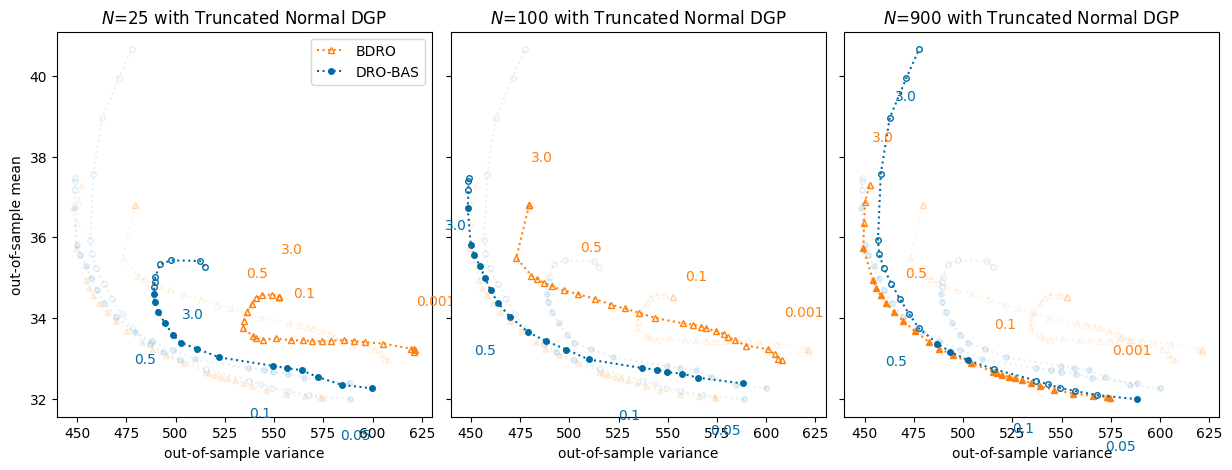

In [13]:
total_samples_sr = agg_df.index.get_level_values("num_total_samples")
TOTAL_SAMPLES = [25, 100, 900]

nrows = len(agg_df.index.get_level_values("dgp").unique())
ncols = len(TOTAL_SAMPLES)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(5*ncols, nrows*5))
fig.subplots_adjust(wspace=0.05)
# fig.suptitle(NiceNameDGP[filter_dgp], fontsize=12)

for j, total_samples in enumerate(TOTAL_SAMPLES):
    df = agg_df.loc[total_samples_sr == total_samples]
    df.loc[:, "is_minimise_pareto_front"] = is_minimise_pareto_front(df["out_of_sample_var"].values, df["out_of_sample_mean"].values)
    gb = df.groupby("dgp")

    for k in range(len(TOTAL_SAMPLES)):
        if j == k:
            alpha = 1.0
            is_labelled = True
            axes[k].set_title("$N$" + f"={total_samples} with {NiceNameDGP[filter_dgp]}")
        else:
            alpha = 0.1
            is_labelled = False
        for i, (group, group_df) in enumerate(gb):
            index_set = set(
                zip(
                    group_df.index.get_level_values("algorithm"),
                    group_df.index.get_level_values("dgp"),
                )
            )
            if k == 0:
                axes[k].set_ylabel("out-of-sample mean")
                axes[k].legend()
            axes[k].set_xlabel("out-of-sample variance")
            
            # add a new plot on the same axis for each parameter setting
            for algorithm, dgp in index_set:
                style = algorithm_style(algorithm)
                line_label = ""
                if k == 0 and j == k:
                    line_label = style.pop("label")
                else:
                    style.pop("label")
                mean_variance_plot(axes[k], group_df.loc[algorithm, dgp, :], **style, alpha=alpha, is_labelled=is_labelled, label=line_label)
# fig.savefig(f"/Users/patrick/downloads/{experiment_name}_{filter_dgp}.pdf", bbox_inches="tight")
fig.show()

## Solve time

In [14]:
results_df["is_warm_start"] = results_df.index.get_level_values("replication") == 0

# solve_time_df = results_df.groupby(["algorithm", "dgp", "num_total_samples", "is_warm_start"]).agg({"solve_time": ["mean", "std"]}).unstack(level="dgp").unstack(level="algorithm")
solve_time_df = results_df.groupby(["algorithm", "num_total_samples", "is_warm_start"]).agg({"solve_time": ["mean", "std"]}).unstack(level="algorithm").swaplevel(1,2, axis="columns")

solve_time_df


solve_time                                
algorithm                           kl_bdro kl_dro_bas   kl_bdro kl_dro_bas
                                       mean       mean       std        std
num_total_samples is_warm_start                                            
25                False            0.010193   0.012743  0.002458   0.002858
                  True             0.063297   0.024675  0.003737   0.004647
100               False            0.026523   0.024803  0.003943   0.006096
                  True             0.155873   0.034372  0.025357   0.001448
900               False            0.237354   0.397472  0.018939   0.124924
                  True             5.569208   0.270292  0.070694   0.017533
2500              False            1.027826   1.791705  0.192305   0.440431
                  True           100.678643   1.069550  0.265628   0.064274

In [15]:
print(solve_time_df.to_latex())

\begin{tabular}{llrrrr}
\toprule
 &  & \multicolumn{4}{r}{solve_time} \\
 & algorithm & kl_bdro & kl_dro_bas & kl_bdro & kl_dro_bas \\
 &  & mean & mean & std & std \\
num_total_samples & is_warm_start &  &  &  &  \\
\midrule
\multirow[t]{2}{*}{25} & False & 0.010193 & 0.012743 & 0.002458 & 0.002858 \\
 & True & 0.063297 & 0.024675 & 0.003737 & 0.004647 \\
\cline{1-6}
\multirow[t]{2}{*}{100} & False & 0.026523 & 0.024803 & 0.003943 & 0.006096 \\
 & True & 0.155873 & 0.034372 & 0.025357 & 0.001448 \\
\cline{1-6}
\multirow[t]{2}{*}{900} & False & 0.237354 & 0.397472 & 0.018939 & 0.124924 \\
 & True & 5.569208 & 0.270292 & 0.070694 & 0.017533 \\
\cline{1-6}
\multirow[t]{2}{*}{2500} & False & 1.027826 & 1.791705 & 0.192305 & 0.440431 \\
 & True & 100.678643 & 1.069550 & 0.265628 & 0.064274 \\
\cline{1-6}
\bottomrule
\end{tabular}



# Constant $G(\tau_n)$ and expected KL

In [16]:

from bayesian_dro.Bayesian_DRO_continuous import DGP_STD_TRUNCATED_NORMAL
from mis_dro.constants import NUM_REPLICATIONS, NUM_OBSERVATIONS, NUM_TEST_OBSERVATIONS
from mis_dro.dataset import sample_dgp
from mis_dro.bayes_conjugates import default_prior_params, get_posterior_params, get_log_partition_constant, derive_analytical_posterior_params
from mis_dro.newsvendor import BACKORDER_COST, HOLDING_COST, newsvendor_cost_cvxpy

def normal_newsvendor_optimal_solution(dgp_mean, dgp_std):
    return sp.stats.norm.ppf(BACKORDER_COST / (BACKORDER_COST + HOLDING_COST), dgp_mean, dgp_std)


def expected_kl_normal_gamma(dgp_mean, dgp_std, theta_params):
    mu_posterior, _, alpha_posterior, beta_posterior = theta_params
    dgp_precision = 1 / (dgp_std ** 2)
    term1 = np.log(np.sqrt(dgp_precision * (beta_posterior / alpha_posterior)))
    term2 = (dgp_std ** 2 + (dgp_mean - mu_posterior)**2) / (2 * (beta_posterior / alpha_posterior))
    return term1 + term2 - 0.5 + get_log_partition_constant("normal_gamma", theta_posterior)

dgp = "multivariate_normal"
posterior = "normal_inverse_wishart"
num_observations = NUM_OBSERVATIONS
G_constant = []             # calculate the constant G
posterior_expected_kl = []  # assuming normal DGP, what is expectation under the posterior of the KL between the DGP and the likelihood?
prior_expected_kl = []      # assuming normal DGP, what is expectation under the prior of the KL between the DGP and the likelihood?
opt_sol = normal_newsvendor_optimal_solution(25, DGP_STD_TRUNCATED_NORMAL)  # optimal solution

opt_costs = np.zeros((NUM_REPLICATIONS, NUM_TEST_OBSERVATIONS))
for j in range(NUM_REPLICATIONS):
    generator = np.random.default_rng(seed=j)
    data = sample_dgp(
        dgp, num_observations, generator=generator
    )
    data_eval = sample_dgp(
        dgp, NUM_TEST_OBSERVATIONS, contamination=0.0, generator=generator
    )
    theta_prior = default_prior_params(posterior)
    theta_posterior = get_posterior_params(posterior, data, theta_prior)
    G_constant.append(get_log_partition_constant(posterior, theta_posterior))
    posterior_expected_kl.append(expected_kl_normal_gamma(25, DGP_STD_TRUNCATED_NORMAL, theta_posterior))
    prior_expected_kl.append(expected_kl_normal_gamma(25, DGP_STD_TRUNCATED_NORMAL, theta_prior))
    opt_costs[j] = newsvendor_cost_cvxpy(opt_sol, data_eval).value
np.max(G_constant), np.var(G_constant)

[[34.40648987]]


ValueError: Dimension mismatch: array 'cov' is of shape (1, 1), but 'mean' is a vector of length 5.

In [ ]:
np.mean(posterior_expected_kl), np.var(posterior_expected_kl)

(0.08892539135699731, 0.0022999465683889984)

In [ ]:
np.mean(prior_expected_kl), np.var(prior_expected_kl)

(359.7442957726813, 0.0)

# Mean squared error between our solution and the solution under the DGP


In [ ]:
mean_cost = np.mean(opt_costs, axis=1)
var_cost = np.var(opt_costs, axis=1)
mean_of_means = np.mean(mean_cost)
mean_of_variances = np.mean(var_cost)
var_of_means = np.var(mean_cost)
opt_sol, mean_of_variances, var_of_means

(31.045853465832373, 809.5869569415518, 16.31412063772674)

In [ ]:
def multivariate_digamma(a: float, p: int) -> float:
    """The multivariate digamma function of dimension p

    Notes:
        [1] https://search.r-project.org/CRAN/refmans/CholWishart/html/mvdigamma.html
        [2] https://en.wikipedia.org/wiki/Multivariate_gamma_function#Derivatives
    """
    return np.sum([sp.special.digamma(a + (1.0-i)/2.0) for i in range(p)])

def get_normal_inverse_wishart_G_constant(dim: int, kappa_post: float) -> float:
    """Returns the constant G(tau, nu) for the normal-inverse-Wishart"""
    term1 = -0.5 * dim * np.log(2)
    print(term1)
    term2 = - 0.5 * multivariate_digamma(0.5 * (kappa_post - dim - 2), dim)
    print(term2)
    term3 = dim / (2 * kappa_post)
    print(term3)
    term4 = dim * 0.5 * np.log(kappa_post - dim - 2)
    print(term4)
    # term5 = 0.5 * np.log(dim)
    # print(term5)
    return term1 + term2 + term3 + term4

In [ ]:
dim = 5
_, kappa_prior, _, _ = default_prior_params("normal_inverse_wishart", dim=dim)
kappa_post = kappa_prior +  20
kappa_prior, kappa_post

(13.0, 33.0)

In [ ]:
get_normal_inverse_wishart_G_constant(dim, kappa_post)

-1.7328679513998633
-6.208643562685282
0.07575757575757576
8.145241345053705


0.2794874067261359